## Phase 2: Exploratory Data Analysis (EDA) 

##3..1 Objectives
The goal of this phase is to move beyond raw data and uncover the underlying patterns of financial behavior in Kenya. Before training our predictive models, we must understand:

- **Feature Distributions:** Identify skewness in financial variables (e.g., income) that could bias model weights.  
- **Feature-Target Relationships:** Visualize how age, education, and digital footprint differ between "High Risk" and "Low Risk" individuals.  
- **Data Quality Audit:** Detect outliers and anomalies that survived the initial cleaning phase. 2.
### 3.2 The "Credit Risk" Lens
In the context of the FinAccess 2021 dataset, we approach this EDA with specific economic hypotheses:

- **The Income Skew:** Income is expected to follow a power-law distribution, where a small number of high earners create a "long tail," necessitating transformation.  
- **The Digital Signal:** Frequent mobile money and mobile banking users may demonstrate higher financial integration, potentially correlating with lower risk.  
- **The Stability Factor:** Older respondents and those with higher formal education are expected to exhibit more stable repayment patterns.


##  1. Data preview and variable definitions

In [16]:
# we omport the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('C:\\Users\\Win\\Alternative credit scoring\\Data\\cleaned_data.csv')
df.head()

,is_high_risk,A19,gender,education,B3I,incomegpnew,B3A__2,B3A__3,mobile_money_usage,mobile_bank_usage,infgp_usage,savings_usage
0,0,59.0,2.0,4.0,13000.0,5.0,1.0,0.0,1.0,3.0,1.0,1.0
1,0,43.0,2.0,4.0,6000.0,4.0,1.0,0.0,1.0,3.0,1.0,1.0
2,0,72.0,1.0,2.0,1000.0,1.0,0.0,0.0,3.0,3.0,1.0,1.0
3,0,22.0,1.0,2.0,2500.0,2.0,0.0,1.0,1.0,3.0,3.0,1.0
4,1,24.0,1.0,3.0,6000.0,4.0,1.0,0.0,1.0,1.0,1.0,1.0


In [5]:
# lets get the shape of our dataset
print(f"The shape of our dataset is:{df.shape[0]} rows and {df.shape[1]} columns")

The shape of our dataset is:19476 rows and 12 columns


In [8]:
#lets list the columns
df.columns

Index(['is_high_risk', 'A19', 'gender', 'education', 'B3I', 'incomegpnew',
       'B3A__2', 'B3A__3', 'mobile_money_usage', 'mobile_bank_usage',
       'infgp_usage', 'savings_usage'],
      dtype='object')

## 1.1 lets define the columns, as they are stated in the metadata
### Variable Definitions

| Column Name            | Variable Type              | Definition / Role |
|-----------------------|----------------------------|-------------------|
| `is_high_risk`         | Target (Binary)            | **1** if the respondent has defaulted, paid late, or experienced severe repayment distress; **0** otherwise. |
| `A19`                  | Numerical (Discrete)       | Age of the respondent. Helps determine the borrower’s lifecycle stage. |
| `gender`               | Categorical                | Biological sex of the respondent. Used to identify gender-based credit access gaps. |
| `education`            | Categorical (Ordinal)      | Highest education level completed. Proxy for human capital and long-term earning potential. |
| `B3I`                  | Numerical (Continuous)     | Monthly income in KSh. Primary indicator of repayment capacity. |
| `incomegpnew`          | Categorical                | Binned income groups, providing a normalized view of economic status. |
| `B3A__2`               | Binary Flag                | Employment income indicator. Shows whether the respondent earns a formal salary. |
| `B3A__3`               | Binary Flag                | Casual work income indicator. Captures reliance on volatile, informal labor. |
| `mobile_money_usage`   | Categorical                | Frequency of using services such as M-Pesa. Represents the respondent’s digital footprint. |
| `mobile_bank_usage`    | Categorical                | Use of banking apps (e.g., M-Shwari, KCB M-Pesa). Indicates financial sophistication. |
| `infgp_usage`          | Categorical                | Participation in Chamas or informal groups. Proxy for social collateral and reliability. |
| `savings_usage`        | Categorical                | Frequency or method of saving. Reflects financial discipline and availability of a financial buffer. |


In [12]:
#lets see the statistical description of our data
# we get the statistical summary of our numericla features: Age and Income
df[['A19','B3I']].describe()

,A19,B3I
count,19476.000000,19476.000000
mean,39.764736,8347.476741
std,17.041139,12519.633845
min,16.000000,100.000000
25%,27.000000,3000.000000
50%,35.000000,5000.000000
75%,50.000000,10000.000000
max,116.000000,400000.000000


###  Numerical Variable Insights
A statistical summary of the continuous variables reveals the following:
* **Economic Reality:** With a median income of 5,000 KSh and a 75th percentile of 10,000 KSh, the dataset represents a low-income demographic where traditional collateral is likely unavailable.
* **Skewness Verification:** The significant gap between the Mean (8,347) and Median (5,000) for income justifies the use of Log Transformation to prevent model bias toward high-income outliers.
* **Demographic Reach:** The interquartile range for age (27–50) indicates the dataset is well-represented by the active labor force.

In [13]:
#lets check for skewness
df[['A19','B3I']].skew()

A19    0.860696
B3I    7.554496
dtype: float64

### Skewness Insights
* **Age (0.86):** Displays a slight right skew, reflecting Kenya's young demographic. This value is within acceptable limits for linear modeling.
* **Income (7.55):** Displays "Extreme Positive Skew." ⚡ 🤯 This indicates that a few high-income outliers dominate the mean. Without transformation, these outliers would distort the model's weight coefficients, leading to poor predictive performance for the median income bracket.

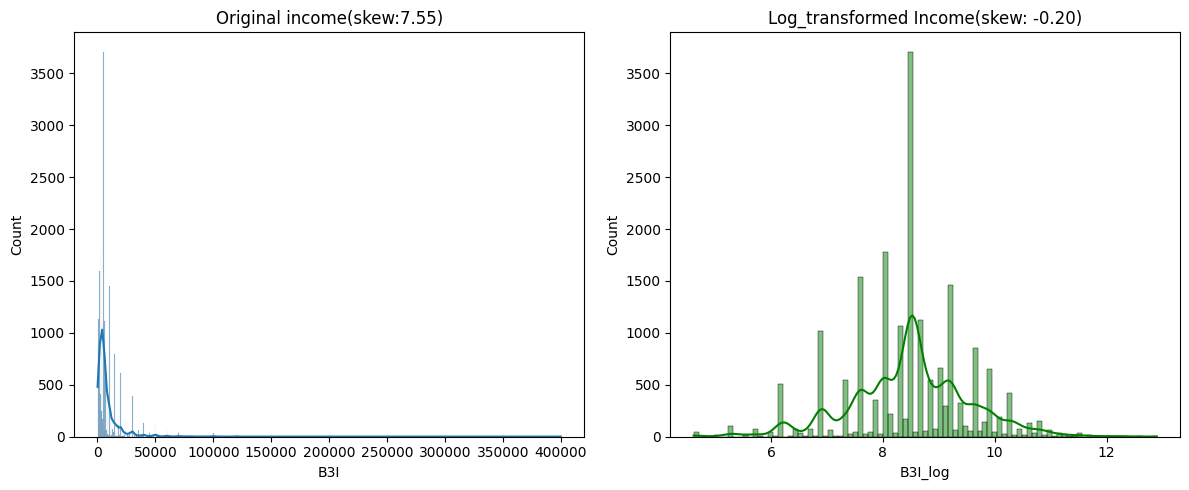

In [18]:
#having seen the skewness of the income, we opt to log_transfornm the Income column
df['B3I_log'] =np.log1p(df['B3I'])
#we now plot the before and after of the icome column
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['B3I'],kde=True)
plt.title(f'Original income(skew:{df['B3I'].skew():.2f})')

plt.subplot(1,2,2)
sns.histplot(df['B3I_log'],kde=True,color='green')
plt.title(f'Log_transformed Income(skew: {df['B3I_log'].skew():.2f})')

plt.tight_layout()
plt.show()

###  Addressing Income Skewness
Our initial analysis revealed a **Skewness of 7.55** for Monthly Income (`B3I`). 
- **Observation:** This indicates a heavy right-tail distribution where extreme outliers could disproportionately influence the model's cost function.
- **Treatment:** We applied a **Natural Log Transformation** ($log(1+x)$).
- **Result:** This transformation effectively normalized the variance, ensuring that the model treats percentage changes in income (e.g., a 10% raise) consistently across different income brackets.